<a href="https://colab.research.google.com/github/dallinmoore/DATA_5630_Deep_Forecasting/blob/main/Homework(my-branch-only)/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW 5 - DATA 5630
Dallin Moore & Alesandro Rodriguez

## Dependencies

In [ ]:
!pip install pycaret[full]

  Using cached shap-0.44.1-cp311-cp311-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (24 kB)
  Using cached interpret-0.6.9-py3-none-any.whl.metadata (1.0 kB)
  Using cached ydata_profiling-4.14.0-py2.py3-none-any.whl.metadata (22 kB)
  Using cached explainerdashboard-0.4.8-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 45.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of flask to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.1 MB/s eta 0:00:00
  Prepari

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sktime.forecasting.model_selection import SlidingWindowSplitter, TimeSeriesSplit
from pycaret.time_series import *

import warnings
warnings.filterwarnings('ignore')

## Question 1


In [ ]:
#1.1
url = "https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/US_macro_Quarterly.csv"
df = pd.read_csv(url, index_col=0)
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [ ]:
#1.2
df.index = pd.to_datetime(df.index)

print(df.index.dtype)


datetime64[ns]


In [ ]:
#1.3
df = df[['cpi']]
df.head()


,cpi
1959-03-31,28.98
1959-06-30,29.15
1959-09-30,29.35
1959-12-31,29.37
1960-03-31,29.54


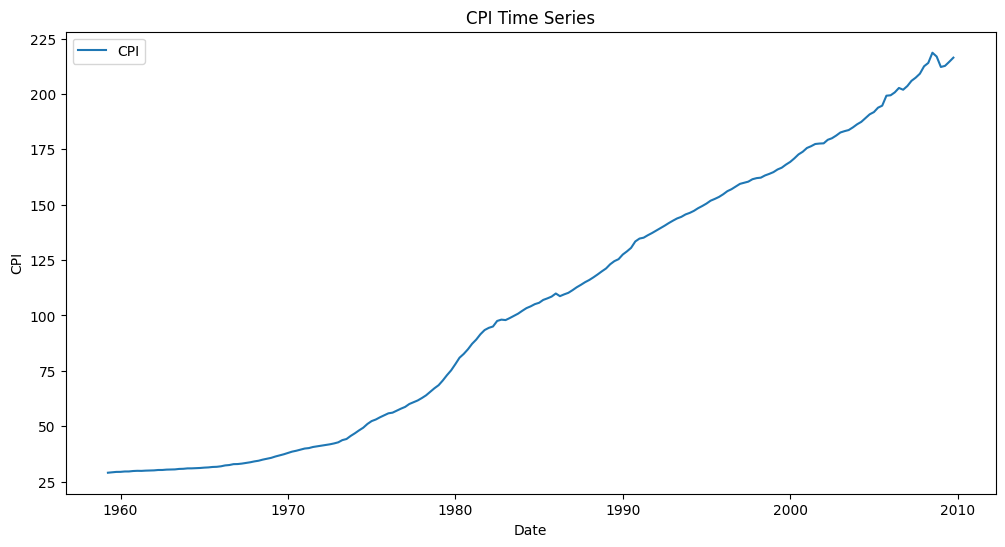

In [ ]:
#1.4
plt.figure(figsize=(12,6))
plt.plot(df, label="CPI")
plt.title("CPI Time Series")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.show()



Without preprocessing it, models will memorize past values instead of generalizing.

In [ ]:
#1.5
df['cpi_lag1'] = df['cpi'].shift(1)
df['cpi_lag2'] = df['cpi'].shift(2)
df['cpi_lag3'] = df['cpi'].shift(3)

# Drop NaN values
df.dropna(inplace=True)

df.head()


,cpi,cpi_lag1,cpi_lag2,cpi_lag3
1959-12-31,29.37,29.35,29.15,28.98
1960-03-31,29.54,29.37,29.35,29.15
1960-06-30,29.55,29.54,29.37,29.35
1960-09-30,29.75,29.55,29.54,29.37
1960-12-31,29.84,29.75,29.55,29.54


In [ ]:
#1.6
test_period = 24
train_period = len(df) - test_period

train = df.iloc[:train_period]
test = df.iloc[train_period:]

X_train = train.drop(columns=['cpi'])
y_train = train['cpi']
X_test = test.drop(columns=['cpi'])
y_test = test['cpi']

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")


Train Shape: (176, 3), Test Shape: (24, 3)


We can you train_test_split() function from sklaearn because a time series model must maintain chronological order. Random train-test splitting would disrupt temporal dependencies.

In [ ]:
#1.7
dt_model = DecisionTreeRegressor(max_depth=10)
dt_model.fit(X_train, y_train)

y_train_pred = dt_model.predict(X_train)

train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
print(f"Train MAPE: {train_mape}")


Train MAPE: 0.0


In [ ]:
y_test_pred = dt_model.predict(X_test)

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
print(f"Test MAPE: {test_mape}")


Test MAPE: 0.08872469814856854


The model looks like it is overfit to the data. A MAPE of 8.9% is pretty low, but since the train set has a MAPE of 0.0, it is probably overfit to the data and we would want to try a decision tree with a depth of less than 10.

The test MAPE can be explained by the fact we are only forecasting ahead with 3 lags and for a horizon of 24. If we increased the horizon it would like increase even more as the values become further and further away.

In [ ]:
#1.8
def forecast_future(model, X_test, y_test, lags, fh):
    X_forecast = X_test.copy()
    forecasts = np.zeros(fh)

    # Forecasting loop
    for i in range(fh):
        next_pred = model.predict(X_forecast)

        if len(next_pred.shape) > 1:
            next_pred = next_pred.flatten()

        forecasts[i] = next_pred[0]

        if i < fh - 1:
            if hasattr(X_forecast, 'values'):
                X_forecast.iloc[0, :-1] = X_forecast.iloc[0, 1:]
                X_forecast.iloc[0, -1] = next_pred[0]
            else:
                X_forecast[0, :-1] = X_forecast[0, 1:]
                X_forecast[0, -1] = next_pred[0]

    # Compute and print MAPE
    mape = mean_absolute_percentage_error(y_test[:fh], forecasts)
    print(f"MAPE: {mape}")

    return forecasts


In [ ]:
forecasts = forecast_future(model=dt_model, X_test=X_test, y_test=y_test, lags=3, fh=24)
forecasts

MAPE: 0.08872469814856854


array([184.9, 184.9, 184.9, 184.9, 184.9, 184.9, 184.9, 184.9, 184.9,
       184.9, 184.9, 184.9, 184.9, 184.9, 184.9, 184.9, 184.9, 184.9,
       184.9, 184.9, 184.9, 184.9, 184.9, 184.9])

We can't use .predict() if we want to do multi step forecast because .predict() will take all of the X_tests and use them to predict all of the y's at once. But, for multistep we want to only use the previous x amount of lags to predict one value at a time. This means that once we are on a forecast horizon greater than the lags, the prediction is only made using previous predictions.

Comparing MAPE in the multi output prediction vs the multi-step prediction are very similar.

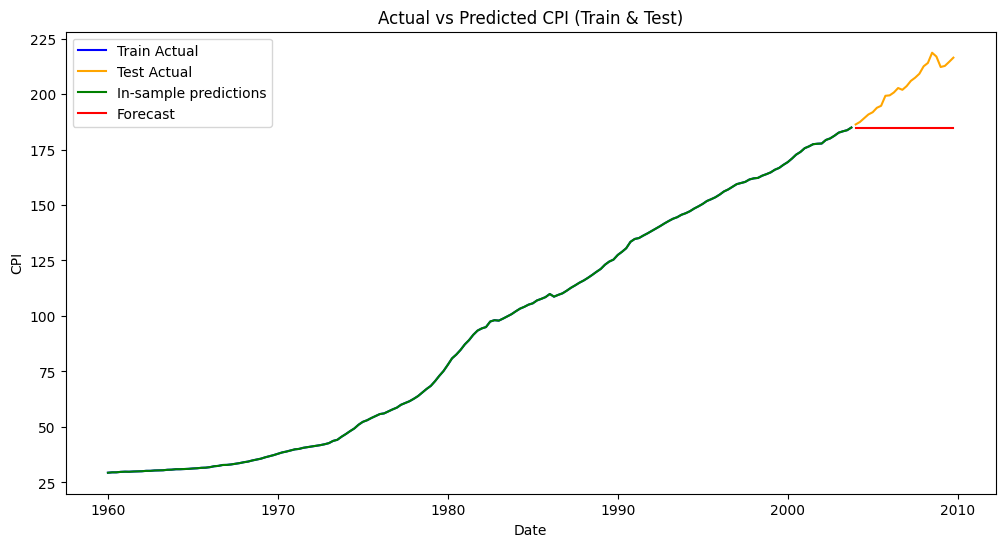

In [ ]:
#1.9
forecast_dates = pd.date_range(start=train.index[-1], periods=24 + 1, freq="Q")[1:]
forecast_df = pd.DataFrame({"Date": forecast_dates, "Forecast": forecasts})
forecast_df.set_index("Date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(train.index, y_train, label="Train Actual", color="blue")
plt.plot(test.index, y_test, label="Test Actual", color="orange")
plt.plot(train.index, y_train_pred, label="In-sample predictions", color="green")
plt.plot(forecast_df.index, forecast_df["Forecast"], label="Forecast", color="red")

plt.title("Actual vs Predicted CPI (Train & Test)")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.show()

The decision tree is performing poorly because the model is likely overfit to the data and memorized it.

In [ ]:
# Reload original dataset
df_original = pd.read_csv(url, index_col=0)
df_original.index = pd.to_datetime(df_original.index)
df_original = df_original[['cpi']]

df_original['diff_cpi'] = df_original['cpi'].diff()

df_original['diff_cpi_lag1'] = df_original['diff_cpi'].shift(1)
df_original['diff_cpi_lag2'] = df_original['diff_cpi'].shift(2)
df_original['diff_cpi_lag3'] = df_original['diff_cpi'].shift(3)

# Drop NaN values
df_original.dropna(inplace=True)

#Splitting data
test_period = 24
train_period = len(df_original) - test_period
train = df_original.iloc[:train_period]
test = df_original.iloc[train_period:]

# Define Features (X) and Target (y)
X_train = train.drop(columns=['cpi', 'diff_cpi'])
y_train = train['diff_cpi']
X_test = test.drop(columns=['cpi', 'diff_cpi'])
y_test = test['diff_cpi']

dt_model = DecisionTreeRegressor(max_depth=10)
dt_model.fit(X_train, y_train)

train_preds_diff = dt_model.predict(X_train)

# Reconstruct actual CPI values from differenced predictions
train_cpi_preds = df_original['cpi'].iloc[0] + np.cumsum(train_preds_diff)

# Store predictions in the dataframe
train['cpi_pred'] = train_cpi_preds

def forecast_future(model, X_test, last_known_cpi):
    # Predict differenced CPI values for the test set
    diff_cpi_forecasts = model.predict(X_test)

    # Reconstruct actual CPI levels
    cpi_forecasts = [last_known_cpi]  # Start with the last known CPI
    for diff in diff_cpi_forecasts:
        cpi_forecasts.append(cpi_forecasts[-1] + diff)  # Add diff_cpi cumulatively

    return cpi_forecasts[1:]  # Remove the initial value to align with the test period

# Get the last known CPI from the train set
last_cpi = train['cpi'].iloc[-1]

# Generate forecasts
cpi_test_forecasts = forecast_future(dt_model, X_test, last_cpi)

# Store predictions in the test DataFrame
test['cpi_pred'] = cpi_test_forecasts

# Display results
test[['cpi', 'cpi_pred']]
mape = mean_absolute_percentage_error(test['cpi'], test['cpi_pred'])

print(f'MAPE for the test set: {mape}%')


MAPE for the test set: 0.013221916071718673%


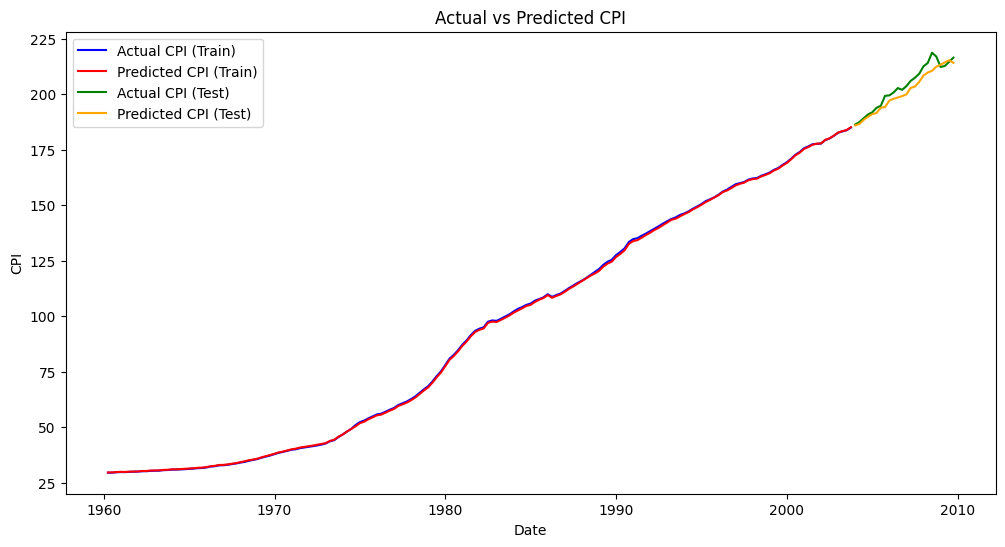

In [ ]:
#1.11
plt.figure(figsize=(12, 6))

# Plot train set actual vs predicted CPI
plt.plot(train.index, train['cpi'], label='Actual CPI (Train)', color='blue')
plt.plot(train.index, train['cpi_pred'], label='Predicted CPI (Train)', color='red', linestyle='-')

# Plot test set actual vs predicted CPI
plt.plot(test.index, test['cpi'], label='Actual CPI (Test)', color='green')
plt.plot(test.index, test['cpi_pred'], label='Predicted CPI (Test)', color='orange', linestyle='-')

# Add labels and legend
plt.title('Actual vs Predicted CPI')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()


In [ ]:
#1.12
from pycaret.time_series import *
exp = TSForecastingExperiment()

df = pd.read_csv(url, index_col=0)
df.index = pd.to_datetime(df.index).to_period('Q')

exp = setup(data = df, target = 'cpi', fh = 24, session_id=1000)


,Description,Value
0,session_id,1000
1,Target,cpi
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(203, 12)"
5,Transformed data shape,"(203, 12)"
6,Transformed train set shape,"(179, 12)"
7,Transformed test set shape,"(24, 12)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [ ]:
best_model = exp.compare_models(cross_validation=False)

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.4704,0.6661,1.2409,2.0957,0.0059,0.0058,0.9556,0.0800
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.4787,0.6833,1.2629,2.1497,0.0060,0.0059,0.9533,0.0700
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.4826,0.6931,1.2733,2.1806,0.0060,0.0060,0.9519,0.1100
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,1.7796,1.7527,4.6950,5.5142,0.0226,0.0229,0.6927,0.0800
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.9263,1.9290,5.0819,6.0690,0.0243,0.0247,0.6278,0.2100
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,2.1272,2.0951,5.6119,6.5915,0.0269,0.0274,0.5609,0.2200
dt_cds_dt,Decision Tree w/ Cond. Deseasonalize & Detrending,2.1408,2.1165,5.6478,6.6589,0.0271,0.0276,0.5519,0.1100
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,2.1585,2.1311,5.6946,6.7048,0.0273,0.0278,0.5457,0.3000
arima,ARIMA,2.1715,2.1340,5.7288,6.7139,0.0274,0.0279,0.5445,1.0600
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,2.1955,2.1668,5.7920,6.8171,0.0278,0.0283,0.5304,0.0800


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

Ridge w/ Cond. Deseasonalize & Detrending was the best model with an $R^2$ of 0.9556. So, the model is an ML model but the Deseasonalization and Detrending are technically econometrics approaches.

Compared to the Decision tree we trained above, PyCaret's model had far better metrics.

In [ ]:
plot_model(best_model)

# Question 2

In [ ]:
stocks = pd.read_csv("https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/yfinance.csv", index_col=0, header=[0,1])
stocks.head()

Adj Close                                                 \
                 AAPL         GLD       MSFT         QQQ         SPY   
Date                                                                   
2018-01-02  40.722874  125.150002  80.229012  152.072800  243.072266   
2018-01-03  40.715786  124.820000  80.602394  153.550400  244.609711   
2018-01-04  40.904907  125.459999  81.311806  153.819046  245.640732   
2018-01-05  41.370617  125.330002  82.319908  155.363861  247.277679   
2018-01-08  41.216949  125.309998  82.403923  155.968399  247.729935   

                                      Close                         ...  \
                 TSLA        USO       AAPL         GLD       MSFT  ...   
Date                                                                ...   
2018-01-02  21.368668  96.559998  43.064999  125.150002  85.949997  ...   
2018-01-03  21.150000  98.720001  43.057499  124.820000  86.349998  ...   
2018-01-04  20.974667  98.959999  43.257500  125.459999  87.110001  ...   
2018-01-05  21.105333  98.480003  43.750000  125.330002  88.190002  ...   
2018-01-08  22.427334  99.040001  43.587502  125.309998  88.279999  ...   

                  Open                           Volume                      \
                   SPY       TSLA        USO       AAPL       GLD      MSFT   
Date                                                                          
2018-01-02  267.839996  20.799999  96.559998  102223600  11762500  22483800   
2018-01-03  268.959991  21.400000  97.360001  118071600   7904300  26061400   
2018-01-04  271.200012  20.858000  98.639999   89738400   7329700  21912000   
2018-01-05  272.510010  21.108000  98.239998   94640000   5739900  23407100   
2018-01-08  273.309998  21.066668  98.480003   82271200   3566700  22113000   

                                                    
                 QQQ       SPY       TSLA      USO  
Date                                                
2018-01-02  32573300  86655700   65283000  1497588  
2018-01-03  29383600  90070400   67822500  2156150  
2018-01-04  24776100  80636400  149194500  1480988  
2018-01-05  26992300  83524000   68868000  1609888  
2018-01-08  23159100  57319200  147891000  1229225  

[5 rows x 42 columns]

In [ ]:
stocks.index

Index(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05', '2018-01-08',
       '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12', '2018-01-16',
       ...
       '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20', '2023-12-21',
       '2023-12-22', '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29'],
      dtype='object', name='Date', length=1509)

In [ ]:
stocks.index = pd.to_datetime(stocks.index).to_period('B')
stocks.index

PeriodIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
             '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
             '2018-01-12', '2018-01-16',
             ...
             '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
             '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
             '2023-12-28', '2023-12-29'],
            dtype='period[B]', name='Date', length=1509)

In [ ]:
df = stocks['Close'][['GLD']]
df.head()

,GLD
Date,
2018-01-02,125.150002
2018-01-03,124.820000
2018-01-04,125.459999
2018-01-05,125.330002
2018-01-08,125.309998


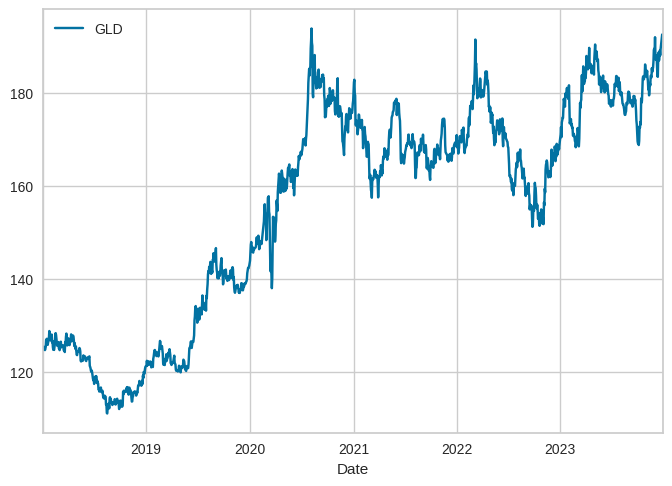

In [ ]:
df.plot()
plt.show()

In [ ]:
df.index

PeriodIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
             '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
             '2018-01-12', '2018-01-16',
             ...
             '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
             '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
             '2023-12-28', '2023-12-29'],
            dtype='period[B]', name='Date', length=1509)

In [ ]:
idx = pd.period_range(min(df.index), max(df.index))
idx

PeriodIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
             '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
             '2018-01-12', '2018-01-15',
             ...
             '2023-12-18', '2023-12-19', '2023-12-20', '2023-12-21',
             '2023-12-22', '2023-12-25', '2023-12-26', '2023-12-27',
             '2023-12-28', '2023-12-29'],
            dtype='period[B]', length=1564)

In [ ]:
df.index.symmetric_difference(idx)

PeriodIndex(['2018-01-15', '2018-02-19', '2018-03-30', '2018-05-28',
             '2018-07-04', '2018-09-03', '2018-11-22', '2018-12-05',
             '2018-12-25', '2019-01-01', '2019-01-21', '2019-02-18',
             '2019-04-19', '2019-05-27', '2019-07-04', '2019-09-02',
             '2019-11-28', '2019-12-25', '2020-01-01', '2020-01-20',
             '2020-02-17', '2020-04-10', '2020-05-25', '2020-07-03',
             '2020-09-07', '2020-11-26', '2020-12-25', '2021-01-01',
             '2021-01-18', '2021-02-15', '2021-04-02', '2021-05-31',
             '2021-07-05', '2021-09-06', '2021-11-25', '2021-12-24',
             '2022-01-17', '2022-02-21', '2022-04-15', '2022-05-30',
             '2022-06-20', '2022-07-04', '2022-09-05', '2022-11-24',
             '2022-12-26', '2023-01-02', '2023-01-16', '2023-02-20',
             '2023-04-07', '2023-05-29', '2023-06-19', '2023-07-04',
             '2023-09-04', '2023-11-23', '2023-12-25'],
            dtype='period[B]')

In [ ]:
df = df.reindex(idx, fill_value=np.nan)
df.tail()

,GLD
2023-12-25,NaN
2023-12-26,191.720001
2023-12-27,192.589996
2023-12-28,191.470001
2023-12-29,191.169998


In [ ]:
df = df.fillna(method='ffill')
df.tail(10)

,GLD
2023-12-18,187.850006
2023-12-19,189.130005
2023-12-20,188.100006
2023-12-21,189.429993
2023-12-22,190.270004
2023-12-25,190.270004
2023-12-26,191.720001
2023-12-27,192.589996
2023-12-28,191.470001
2023-12-29,191.169998


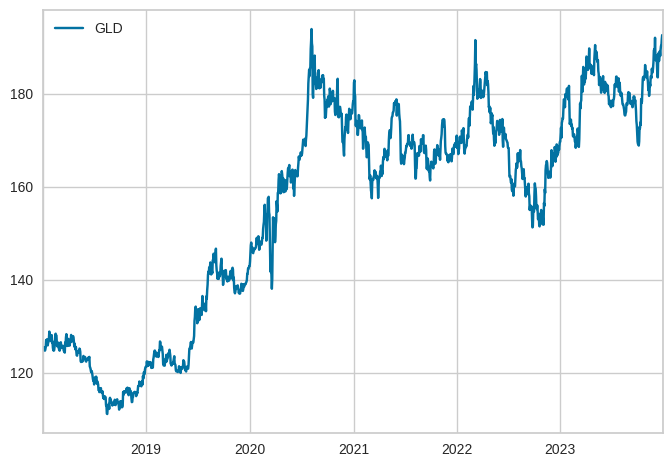

In [ ]:
df.plot()
plt.show()

In [ ]:
ts = np.arange(10)
splitter = SlidingWindowSplitter(fh=np.arange(1,3), window_length=3, step_length=1)
list(splitter.split(ts))

[(array([0, 1, 2]), array([3, 4])),
 (array([1, 2, 3]), array([4, 5])),
 (array([2, 3, 4]), array([5, 6])),
 (array([3, 4, 5]), array([6, 7])),
 (array([4, 5, 6]), array([7, 8])),
 (array([5, 6, 7]), array([8, 9]))]

In [ ]:
df.size

1564

In [ ]:
exp = TSForecastingExperiment()
exp.setup(data = df, target='GLD' ,coverage=0.90, fold_strategy=SlidingWindowSplitter(fh=np.arange(1,23), window_length=130, step_length=130))

,Description,Value
0,session_id,5942
1,Target,GLD
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(1564, 1)"
5,Transformed data shape,"(1564, 1)"
6,Transformed train set shape,"(1542, 1)"
7,Transformed test set shape,"(22, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,SlidingWindowSplitter


In [ ]:
exp.plot_model(plot='train_test_split')

In [ ]:
exp.plot_model(plot='cv')

In [ ]:
exp.compare_models(sort='rmse')

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,3.0318,2.6231,3.1692,3.7343,0.0194,0.0195,-1.6914,0.0945
exp_smooth,Exponential Smoothing,3.0319,2.6232,3.1693,3.7344,0.0194,0.0195,-1.6915,0.0400
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,3.1362,2.6773,3.2301,3.7551,0.0200,0.0201,-1.7246,0.4745
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,3.0652,2.6556,3.2483,3.8020,0.0199,0.0200,-1.6534,0.5445
theta,Theta Forecaster,3.2032,2.7730,3.2713,3.8717,0.0202,0.0204,-1.9947,0.0700
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,3.2395,2.7754,3.3807,3.9255,0.0209,0.0209,-1.9513,0.9691
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,3.3137,2.8262,3.4507,3.9862,0.0213,0.0213,-2.0551,0.6482
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,3.6655,3.0773,3.5129,4.0626,0.0222,0.0223,-2.7846,0.7373
naive,Naive Forecaster,3.3667,2.9112,3.4404,4.0639,0.0213,0.0214,-2.2461,0.6100
auto_arima,Auto ARIMA,3.6745,3.1493,3.7138,4.3592,0.0229,0.0232,-2.8283,0.8609


Processing:   0%|          | 0/113 [00:00<?, ?it/s]

AutoETS(trend='add')

In [ ]:
my_models = ['naive','ets', 'arima', 'rf_cds_dt', 'knn_cds_dt', 'xgboost_cds_dt', 'lightgbm_cds_dt', 'catboost_cds_dt' , 'gbr_cds_dt']
exp.compare_models(include=my_models, sort='rmse')

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
ets,ETS,3.0318,2.6231,3.1692,3.7343,0.0194,0.0195,-1.6914,0.0600
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,3.0652,2.6556,3.2483,3.8020,0.0199,0.0200,-1.6534,0.6473
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,3.2395,2.7754,3.3807,3.9255,0.0209,0.0209,-1.9513,0.8773
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,3.3137,2.8262,3.4507,3.9862,0.0213,0.0213,-2.0551,0.4364
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,3.6655,3.0773,3.5129,4.0626,0.0222,0.0223,-2.7846,0.7764
naive,Naive Forecaster,3.3667,2.9112,3.4404,4.0639,0.0213,0.0214,-2.2461,0.0455
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,3.7221,3.1523,3.9232,4.5163,0.0241,0.0241,-2.8176,0.8264
xgboost_cds_dt,Extreme Gradient Boosting w/ Cond. Deseasonalize & Detrending,4.4955,3.6915,4.2303,4.8104,0.0269,0.0271,-6.9093,0.4273
arima,ARIMA,4.6309,3.9316,4.4939,5.2122,0.0283,0.0286,-5.1180,0.2345


Processing:   0%|          | 0/41 [00:00<?, ?it/s]

AutoETS(trend='add')

In [ ]:
ets = exp.create_model('ets')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,1.5816,1.3510,0.8669,1.0065,0.0074,0.0074,0.4040
1,2018-12-31,1.6805,1.6289,0.8379,1.1218,0.0069,0.0068,-0.4363
2,2019-07-01,3.7149,2.9675,2.1653,2.3836,0.0161,0.0163,-3.5415
3,2019-12-30,3.6263,2.9973,3.0203,3.2648,0.0205,0.0208,-3.5504
4,2020-06-29,2.5582,2.9022,3.6059,5.7131,0.0202,0.0207,-0.0705
5,2020-12-28,2.4066,1.8167,3.3908,3.7243,0.0193,0.0193,-0.2497
6,2021-06-28,2.6589,2.0969,3.0306,3.3310,0.0179,0.0181,-4.0327
7,2021-12-27,1.1775,1.0484,1.0728,1.3192,0.0063,0.0063,0.1628
8,2022-06-27,5.8564,5.0079,7.4181,8.2954,0.0461,0.0448,-4.1344
9,2022-12-26,6.6821,5.7871,7.7305,8.8817,0.0436,0.0449,-3.3470


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_ets = exp.tune_model(ets)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,1.5853,1.3531,0.8690,1.0080,0.0074,0.0074,0.4022
1,2018-12-31,1.5545,1.5045,0.7751,1.0362,0.0064,0.0063,-0.2253
2,2019-07-01,3.6759,2.9416,2.1426,2.3627,0.0160,0.0161,-3.4625
3,2019-12-30,3.5069,2.9028,2.9208,3.1619,0.0199,0.0201,-3.2680
4,2020-06-29,2.3797,2.7536,3.3542,5.4207,0.0187,0.0192,0.0363
5,2020-12-28,2.5615,1.9151,3.6091,3.9261,0.0206,0.0205,-0.3888
6,2021-06-28,2.4975,1.9678,2.8466,3.1259,0.0168,0.0170,-3.4321
7,2021-12-27,1.1665,1.0221,1.0626,1.2861,0.0063,0.0063,0.2042
8,2022-06-27,5.9792,5.1115,7.5736,8.4669,0.0471,0.0458,-4.3489
9,2022-12-26,6.5175,5.6462,7.5401,8.6655,0.0426,0.0438,-3.1380


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 11 folds for each of 6 candidates, totalling 66 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  66 out of  66 | elapsed:    5.7s finished


In [ ]:
arima = exp.create_model('arima')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,4.5213,3.9014,2.4783,2.9065,0.0213,0.0210,-3.9703
1,2018-12-31,4.1655,3.5950,2.0770,2.4759,0.0169,0.0172,-5.9958
2,2019-07-01,7.6863,5.9231,4.4801,4.7576,0.0334,0.0341,-17.0936
3,2019-12-30,6.2874,5.1660,5.2365,5.6271,0.0356,0.0364,-12.5175
4,2020-06-29,6.1459,5.6126,8.6629,11.0488,0.0491,0.0511,-3.0038
5,2020-12-28,2.1987,1.6992,3.0979,3.4834,0.0176,0.0176,-0.0933
6,2021-06-28,1.0295,0.9080,1.1734,1.4424,0.0069,0.0070,0.0564
7,2021-12-27,2.1859,1.9413,1.9914,2.4427,0.0117,0.0118,-1.8706
8,2022-06-27,6.9066,5.8758,8.7484,9.7330,0.0544,0.0526,-6.0683
9,2022-12-26,7.8128,6.7172,9.0387,10.3092,0.0511,0.0528,-4.8567


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_arima = exp.tune_model(arima)

In [ ]:
xgboost = exp.create_model('xgboost_cds_dt')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,2.0824,1.7400,1.1414,1.2962,0.0098,0.0097,0.0114
1,2018-12-31,3.3437,2.7467,1.6672,1.8916,0.0136,0.0137,-3.0837
2,2019-07-01,13.9029,10.2384,8.1035,8.2237,0.0606,0.0625,-53.0612
3,2019-12-30,4.0600,3.3617,3.3814,3.6617,0.0230,0.0233,-4.7240
4,2020-06-29,4.3467,3.9923,6.1269,7.8590,0.0347,0.0357,-1.0257
5,2020-12-28,1.9286,1.8438,2.7174,3.7800,0.0153,0.0154,-0.2874
6,2021-06-28,2.1543,1.7098,2.4554,2.7160,0.0145,0.0146,-2.3458
7,2021-12-27,1.7453,1.4736,1.5900,1.8542,0.0093,0.0094,-0.6541
8,2022-06-27,8.0396,6.5613,10.1835,10.8685,0.0632,0.0610,-7.8138
9,2022-12-26,6.5423,5.7284,7.5688,8.7916,0.0427,0.0440,-3.2594


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_xgboost = exp.tune_model(xgboost)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,1.2220,1.0983,0.6698,0.8182,0.0057,0.0057,0.6061
1,2018-12-31,2.3202,2.0438,1.1569,1.4075,0.0095,0.0095,-1.2610
2,2019-07-01,3.1590,2.8127,1.8413,2.2592,0.0138,0.0138,-3.0800
3,2019-12-30,7.5300,6.2883,6.2715,6.8495,0.0426,0.0438,-19.0287
4,2020-06-29,4.0682,3.7832,5.7342,7.4475,0.0327,0.0335,-0.8191
5,2020-12-28,2.9644,2.3984,4.1769,4.9171,0.0236,0.0240,-1.1783
6,2021-06-28,3.4506,2.9717,3.9329,4.7205,0.0233,0.0229,-9.1074
7,2021-12-27,2.2427,1.9572,2.0431,2.4627,0.0120,0.0120,-1.9180
8,2022-06-27,2.0519,1.8513,2.5990,3.0666,0.0160,0.0160,0.2983
9,2022-12-26,2.7986,2.4071,3.2377,3.6942,0.0183,0.0185,0.2479


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 11 folds for each of 10 candidates, totalling 110 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   20.3s
[Parallel(n_jobs=-1)]: Done 110 out of 110 | elapsed:   49.5s finished


In [ ]:
knn = exp.create_model('knn_cds_dt')

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,2.1126,1.8025,1.1580,1.3428,0.0099,0.0099,-0.0609
1,2018-12-31,1.8561,1.8082,0.9255,1.2453,0.0075,0.0076,-0.7698
2,2019-07-01,1.8907,1.6605,1.1021,1.3337,0.0082,0.0083,-0.4220
3,2019-12-30,4.4149,3.6178,3.6770,3.9406,0.0250,0.0254,-5.6293
4,2020-06-29,2.8548,3.0919,4.0239,6.0866,0.0226,0.0232,-0.2150
5,2020-12-28,2.2106,1.6934,3.1148,3.4717,0.0178,0.0177,-0.0859
6,2021-06-28,2.1211,1.6775,2.4176,2.6648,0.0143,0.0144,-2.2210
7,2021-12-27,1.2968,1.1752,1.1814,1.4788,0.0070,0.0070,-0.0521
8,2022-06-27,6.7049,5.6492,8.4928,9.3577,0.0528,0.0511,-5.5337
9,2022-12-26,6.9580,5.9338,8.0497,9.1069,0.0455,0.0468,-3.5703


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_knn = exp.tune_model(knn)

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2018-07-02,2.5406,2.1995,1.3926,1.6386,0.0120,0.0119,-0.5797
1,2018-12-31,2.2708,2.0926,1.1322,1.4412,0.0092,0.0093,-1.3704
2,2019-07-01,8.5168,6.3301,4.9642,5.0845,0.0371,0.0378,-19.6656
3,2019-12-30,4.5781,3.8234,3.8130,4.1646,0.0259,0.0263,-6.4043
4,2020-06-29,2.6991,2.9479,3.8045,5.8032,0.0213,0.0219,-0.1045
5,2020-12-28,1.7466,1.4110,2.4610,2.8926,0.0140,0.0140,0.2461
6,2021-06-28,2.0157,1.6043,2.2975,2.5484,0.0136,0.0137,-1.9457
7,2021-12-27,1.5150,1.3962,1.3801,1.7568,0.0081,0.0081,-0.4849
8,2022-06-27,6.3717,5.3250,8.0708,8.8207,0.0501,0.0487,-4.8053
9,2022-12-26,7.0744,6.0236,8.1843,9.2447,0.0463,0.0476,-3.7097


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 11 folds for each of 10 candidates, totalling 110 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 110 out of 110 | elapsed:  1.1min finished


In [ ]:
exp.plot_model(estimator=tuned_ets, plot='diagnostics')

In [ ]:
exp.plot_model(tuned_ets, plot='insample')

In [ ]:
exp.plot_model(tuned_ets, plot='forecast', data_kwargs={'fh':36})

In [ ]:
exp.plot_model(xgboost, plot='forecast', data_kwargs={'fh':36})

In [ ]:
holdout_pred = exp.predict_model(tuned_ets)

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,ETS,2.1456,1.8932,2.1236,2.6952,0.0114,0.0113,-0.2642


In [ ]:
holdout_pred

,y_pred
2023-11-30,189.5889
2023-12-01,189.6379
2023-12-04,189.6868
2023-12-05,189.7357
2023-12-06,189.7847
2023-12-07,189.8336
2023-12-08,189.8826
2023-12-11,189.9315
2023-12-12,189.9804
2023-12-13,190.0294


In [ ]:
final_model = exp.finalize_model(tuned_ets)

In [ ]:
exp.plot_model(final_model, plot='forecast', data_kwargs={'fh':24})

In [ ]:
unseen_predictions = exp.predict_model(final_model, fh=10)
unseen_predictions

,y_pred
2024-01-01,191.2193
2024-01-02,191.2686
2024-01-03,191.3179
2024-01-04,191.3672
2024-01-05,191.4165
2024-01-08,191.4658
2024-01-09,191.5151
2024-01-10,191.5644
2024-01-11,191.6137
2024-01-12,191.6630


ETS is the best model for our asset pricing prediction